In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.special import rel_entr
import glob
import os


def load_ps2d_for_i(i):
    pattern = f"plot_{i}/point_*/ps2d.npy"
    files = sorted(glob.glob(pattern))

    all_ps_i = np.array([np.load(f) for f in files])

    print(f"i={i}: {len(files)} réalisations")
    print(f"Shape: {all_ps_i.shape}")

    return all_ps_i

def load_xhi_for_i(i):
    pattern = f"plot_{i}/point_*/xHI.npy"
    files = sorted(glob.glob(pattern))

    all_xhi_i = np.array([np.load(f) for f in files])

    print(f"i={i}: {len(files)} réalisations")
    print(f"Shape: {all_xhi_i.shape}")

    return all_xhi_i.mean(axis=0)

def compute_dkl_gaussian(x, bins=50, eps=1e-12):

    x = np.asarray(x)
    x = x[np.isfinite(x)]

    if len(x) < 2 or np.std(x) < eps:
        return np.nan

    mu = np.mean(x)
    sigma = np.std(x, ddof=1)

    hist, edges = np.histogram(
        x,
        bins=bins,
        density=False
    )

    p = hist.astype(float)
    p /= p.sum()

    q = norm.cdf(
        edges[1:], mu, sigma
    ) - norm.cdf(
        edges[:-1], mu, sigma
    )

    q = q / q.sum()

    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)

    p /= p.sum()
    q /= q.sum()

    return np.sum(rel_entr(p, q))

from scipy.stats import gaussian_kde, norm

def compute_dkl_kde(x, num_points=200, eps=1e-12):
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if len(x) < 2 or np.std(x) < eps:
        return np.nan

    # Estimation continue par Kernel
    kde = gaussian_kde(x)
    
    # Grille d'évaluation
    grid = np.linspace(x.min() - 3*x.std(), x.max() + 3*x.std(), num_points)
    dx = grid[1] - grid[0]

    # Probabilités p(x) et q(x)
    p = kde(grid)
    q = norm.pdf(grid, np.mean(x), np.std(x, ddof=1))

    # Normalisation
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    
    # Intégration numérique de p * log(p / q)
    return np.sum(p * np.log(p / q)) * dx

In [2]:
import numpy as np
import matplotlib.pyplot as plt

n_i = 30
z = 0

dkl_map_list = []

# ----------------------------------
# Calculer la DKL pour chaque i
# ----------------------------------
for i in range(n_i):

    all_ps_i = load_ps2d_for_i(i)

    N, redshift, H, W = all_ps_i.shape

    dkl_map = np.zeros((H, W))

    for x in range(H):
        for y in range(W):

            values = all_ps_i[:, z, x, y]

            dkl_map[x, y] = compute_dkl_gaussian(
                values,
                bins=50
            )

    dkl_map_list.append(dkl_map)

# Shape : (20, H, W)
dkl_map_array = np.array(dkl_map_list)

print(dkl_map_array.shape)

i=0: 200 réalisations
Shape: (200, 3, 10, 10)
i=1: 200 réalisations
Shape: (200, 3, 10, 10)
i=2: 200 réalisations
Shape: (200, 3, 10, 10)
i=3: 200 réalisations
Shape: (200, 3, 10, 10)
i=4: 199 réalisations
Shape: (199, 3, 10, 10)
i=5: 199 réalisations
Shape: (199, 3, 10, 10)
i=6: 199 réalisations
Shape: (199, 3, 10, 10)
i=7: 199 réalisations
Shape: (199, 3, 10, 10)
i=8: 199 réalisations
Shape: (199, 3, 10, 10)
i=9: 199 réalisations
Shape: (199, 3, 10, 10)
i=10: 199 réalisations
Shape: (199, 3, 10, 10)
i=11: 199 réalisations
Shape: (199, 3, 10, 10)
i=12: 199 réalisations
Shape: (199, 3, 10, 10)
i=13: 199 réalisations
Shape: (199, 3, 10, 10)
i=14: 199 réalisations
Shape: (199, 3, 10, 10)
i=15: 199 réalisations
Shape: (199, 3, 10, 10)
i=16: 199 réalisations
Shape: (199, 3, 10, 10)
i=17: 199 réalisations
Shape: (199, 3, 10, 10)
i=18: 199 réalisations
Shape: (199, 3, 10, 10)
i=19: 199 réalisations
Shape: (199, 3, 10, 10)
i=20: 201 réalisations
Shape: (201, 3, 10, 10)
i=21: 201 réalisations


In [3]:
list_xhi = [load_xhi_for_i(i)[0] for i in range(n_i)]

i=0: 200 réalisations
Shape: (200, 3)
i=1: 200 réalisations
Shape: (200, 3)
i=2: 200 réalisations
Shape: (200, 3)
i=3: 200 réalisations
Shape: (200, 3)
i=4: 199 réalisations
Shape: (199, 3)
i=5: 199 réalisations
Shape: (199, 3)
i=6: 199 réalisations
Shape: (199, 3)
i=7: 199 réalisations
Shape: (199, 3)
i=8: 199 réalisations
Shape: (199, 3)
i=9: 199 réalisations
Shape: (199, 3)
i=10: 199 réalisations
Shape: (199, 3)
i=11: 199 réalisations
Shape: (199, 3)
i=12: 199 réalisations
Shape: (199, 3)
i=13: 199 réalisations
Shape: (199, 3)
i=14: 199 réalisations
Shape: (199, 3)
i=15: 199 réalisations
Shape: (199, 3)
i=16: 199 réalisations
Shape: (199, 3)
i=17: 199 réalisations
Shape: (199, 3)
i=18: 199 réalisations
Shape: (199, 3)
i=19: 199 réalisations
Shape: (199, 3)
i=20: 201 réalisations
Shape: (201, 3)
i=21: 201 réalisations
Shape: (201, 3)
i=22: 201 réalisations
Shape: (201, 3)
i=23: 201 réalisations
Shape: (201, 3)
i=24: 201 réalisations
Shape: (201, 3)
i=25: 201 réalisations
Shape: (201,

In [10]:
list_xhi = np.array(list_xhi)
print(list_xhi)

[1.8379740e-05 5.3242866e-02 1.0521787e-01 1.5559760e-01 2.1034834e-01
 2.6207384e-01 3.1683961e-01 3.6727074e-01 4.1865256e-01 4.7253796e-01
 5.2543700e-01 5.7760531e-01 6.3101470e-01 6.9231045e-01 7.3555309e-01
 7.9680359e-01 8.3321947e-01 8.8089681e-01 9.4693768e-01 9.9999964e-01
 9.5114076e-01 9.6269929e-01 9.6634948e-01 9.6663439e-01 9.7916281e-01
 9.7697622e-01 9.8443043e-01 9.8663765e-01 9.9231601e-01 9.9362564e-01]


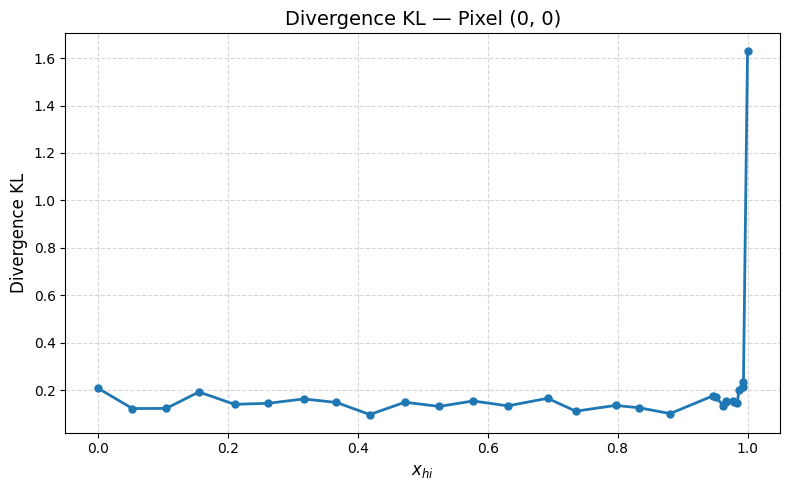

In [ ]:
n_i = 30

dkl_map_array = np.array(dkl_map_list)

# Trier list_xhi et réordonner les valeurs DKL correspondantes
sort_idx = np.argsort(list_xhi)

xhi_sorted = np.array(list_xhi)[sort_idx]
dkl_values = dkl_map_array[:, 0, 0][sort_idx]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    xhi_sorted,
    dkl_values,
    marker='o',
    markersize=5,
    linewidth=2
)

ax.set_title("Divergence KL — Pixel (0, 0)", fontsize=14)
ax.set_xlabel("$x_{hi}$", fontsize=12)
ax.set_ylabel("Divergence KL", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

i=0: 200 réalisations
Shape: (200, 3, 10, 10)
i=1: 200 réalisations
Shape: (200, 3, 10, 10)
i=2: 200 réalisations
Shape: (200, 3, 10, 10)
i=3: 200 réalisations
Shape: (200, 3, 10, 10)
i=4: 199 réalisations
Shape: (199, 3, 10, 10)
i=5: 199 réalisations
Shape: (199, 3, 10, 10)
i=6: 199 réalisations
Shape: (199, 3, 10, 10)
i=7: 199 réalisations
Shape: (199, 3, 10, 10)
i=8: 199 réalisations
Shape: (199, 3, 10, 10)
i=9: 199 réalisations
Shape: (199, 3, 10, 10)
i=10: 199 réalisations
Shape: (199, 3, 10, 10)
i=11: 199 réalisations
Shape: (199, 3, 10, 10)
i=12: 199 réalisations
Shape: (199, 3, 10, 10)
i=13: 199 réalisations
Shape: (199, 3, 10, 10)
i=14: 199 réalisations
Shape: (199, 3, 10, 10)
i=15: 199 réalisations
Shape: (199, 3, 10, 10)
i=16: 199 réalisations
Shape: (199, 3, 10, 10)
i=17: 199 réalisations
Shape: (199, 3, 10, 10)
i=18: 199 réalisations
Shape: (199, 3, 10, 10)
i=19: 199 réalisations
Shape: (199, 3, 10, 10)
i=20: 201 réalisations
Shape: (201, 3, 10, 10)
i=21: 201 réalisations


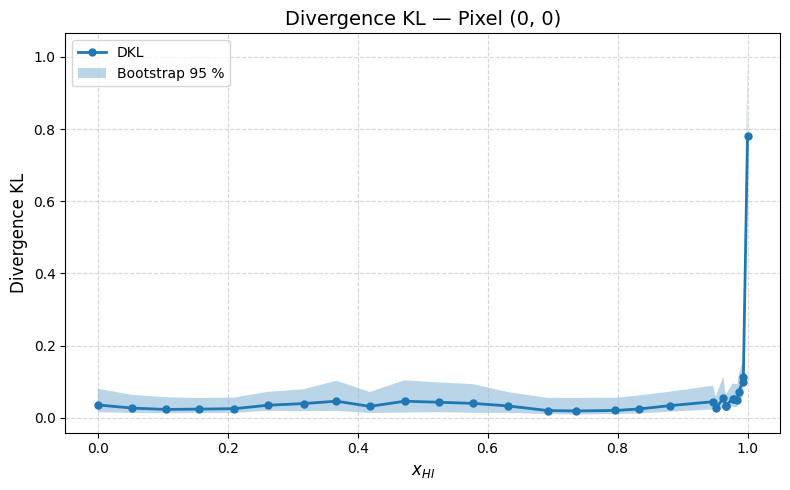

In [15]:
import numpy as np
import matplotlib.pyplot as plt

n_i = 30
n_boot = 1000

dkl_values = []
dkl_low = []
dkl_high = []

x, y = 0, 0
z = 0

for i in range(n_i):

    all_ps_i = load_ps2d_for_i(i)
    values = all_ps_i[:, z, x, y]

    # DKL originale par KDE
    dkl = compute_dkl_kde(values)

    # Bootstrap
    dkl_boot = []
    for _ in range(n_boot):
        sample = np.random.choice(
            values,
            size=len(values),
            replace=True
        )
        dkl_boot.append(compute_dkl_kde(sample))

    # Intervalle 95 %
    low, high = np.percentile(dkl_boot, [2.5, 97.5])

    dkl_values.append(dkl)
    dkl_low.append(low)
    dkl_high.append(high)


# Conversion en tableaux
dkl_values = np.array(dkl_values)
dkl_low = np.array(dkl_low)
dkl_high = np.array(dkl_high)

# Trier selon xHI
sort_idx = np.argsort(list_xhi)

xhi_sorted = np.array(list_xhi)[sort_idx]
dkl_sorted = dkl_values[sort_idx]
low_sorted = dkl_low[sort_idx]
high_sorted = dkl_high[sort_idx]


# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    xhi_sorted,
    dkl_sorted,
    marker='o',
    markersize=5,
    linewidth=2,
    label="DKL"
)

ax.fill_between(
    xhi_sorted,
    low_sorted,
    high_sorted,
    alpha=0.3,
    label="Bootstrap 95 %"
)

ax.set_title("Divergence KL — Pixel (0, 0)", fontsize=14)
ax.set_xlabel("$x_{HI}$", fontsize=12)
ax.set_ylabel("Divergence KL", fontsize=12)

ax.grid(True, linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

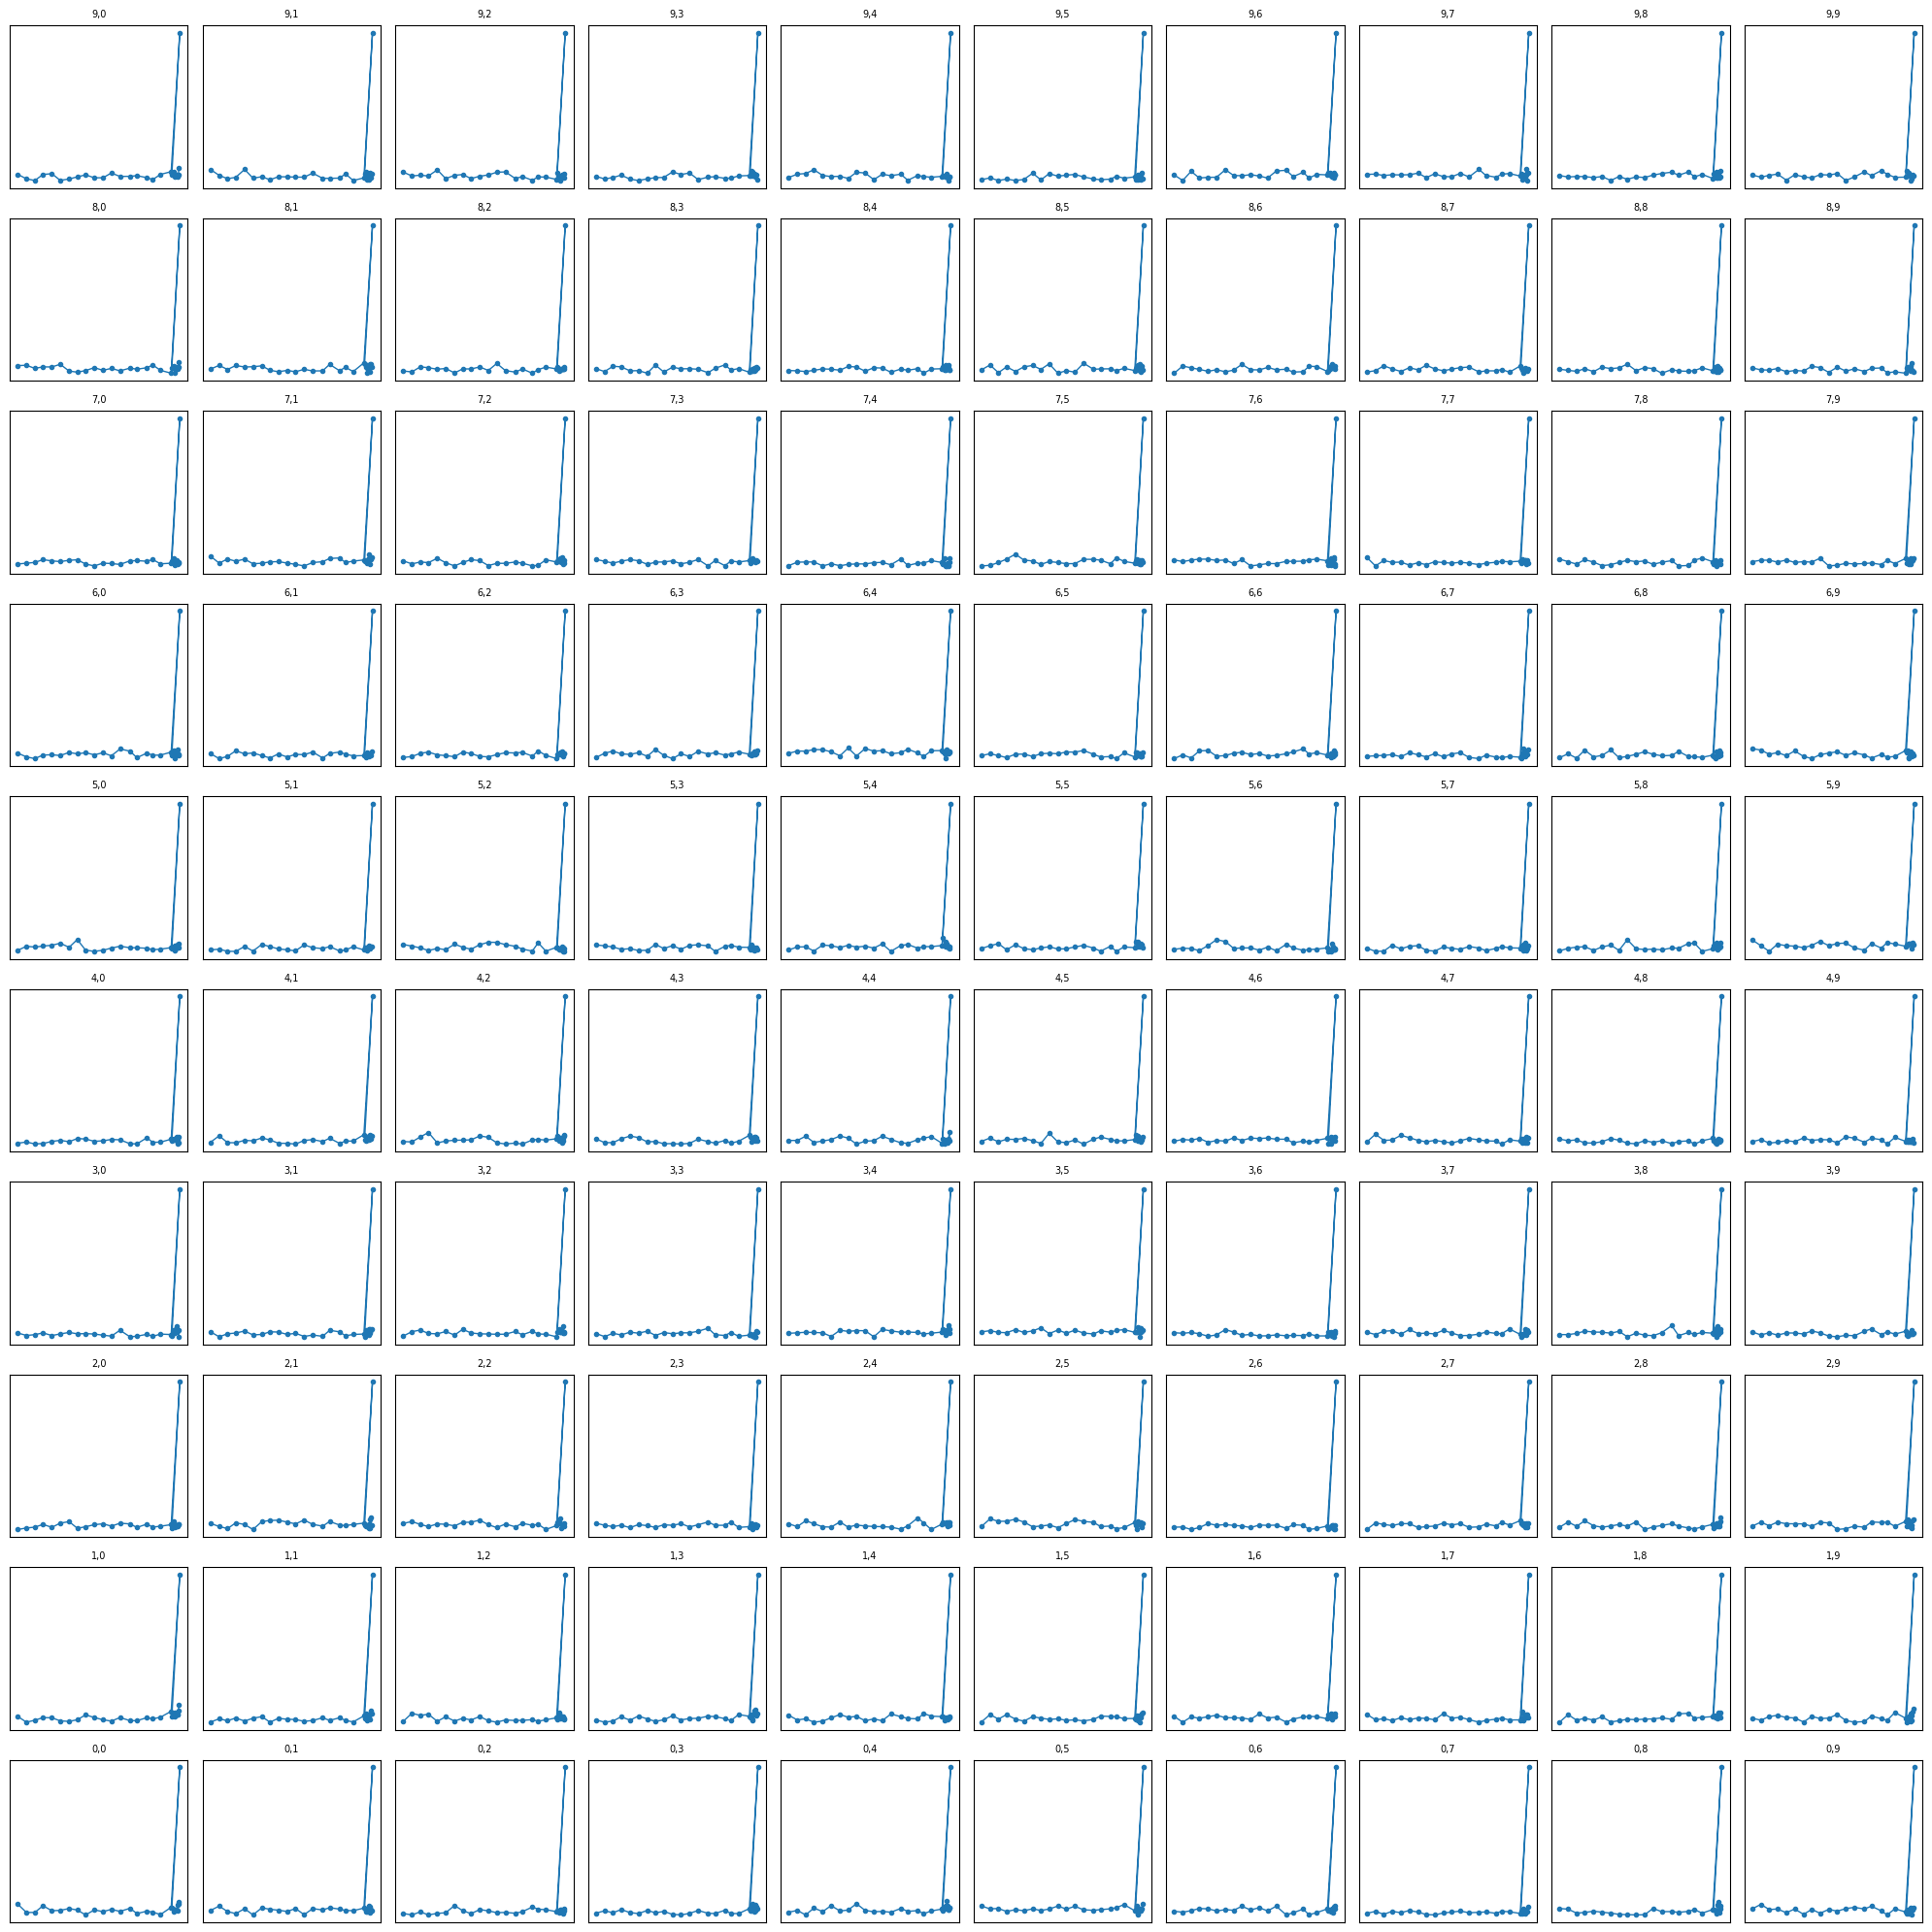

In [7]:
n_i = 30

dkl_map_array = np.array(dkl_map_list)
fig, axes = plt.subplots(
    H, W,
    figsize=(20, 20),
    sharex=True
)

for x in range(H):
    for y in range(W):

        ax = axes[H - 1 - x, y]

        dkl_values = dkl_map_array[:, x, y]

        ax.plot(
            list_xhi,
            dkl_values,
            marker='o',
            markersize=3,
            linewidth=1
        )

        ax.set_title(
            f"{x},{y}",
            fontsize=7
        )

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(
    dkl_map,
    origin="lower",
    cmap="viridis"
)

plt.colorbar(label="DKL(P || Gaussian)")
plt.xlabel("y")
plt.ylabel("x")
plt.title(f"DKL map — i={i}")

plt.tight_layout()
plt.show()

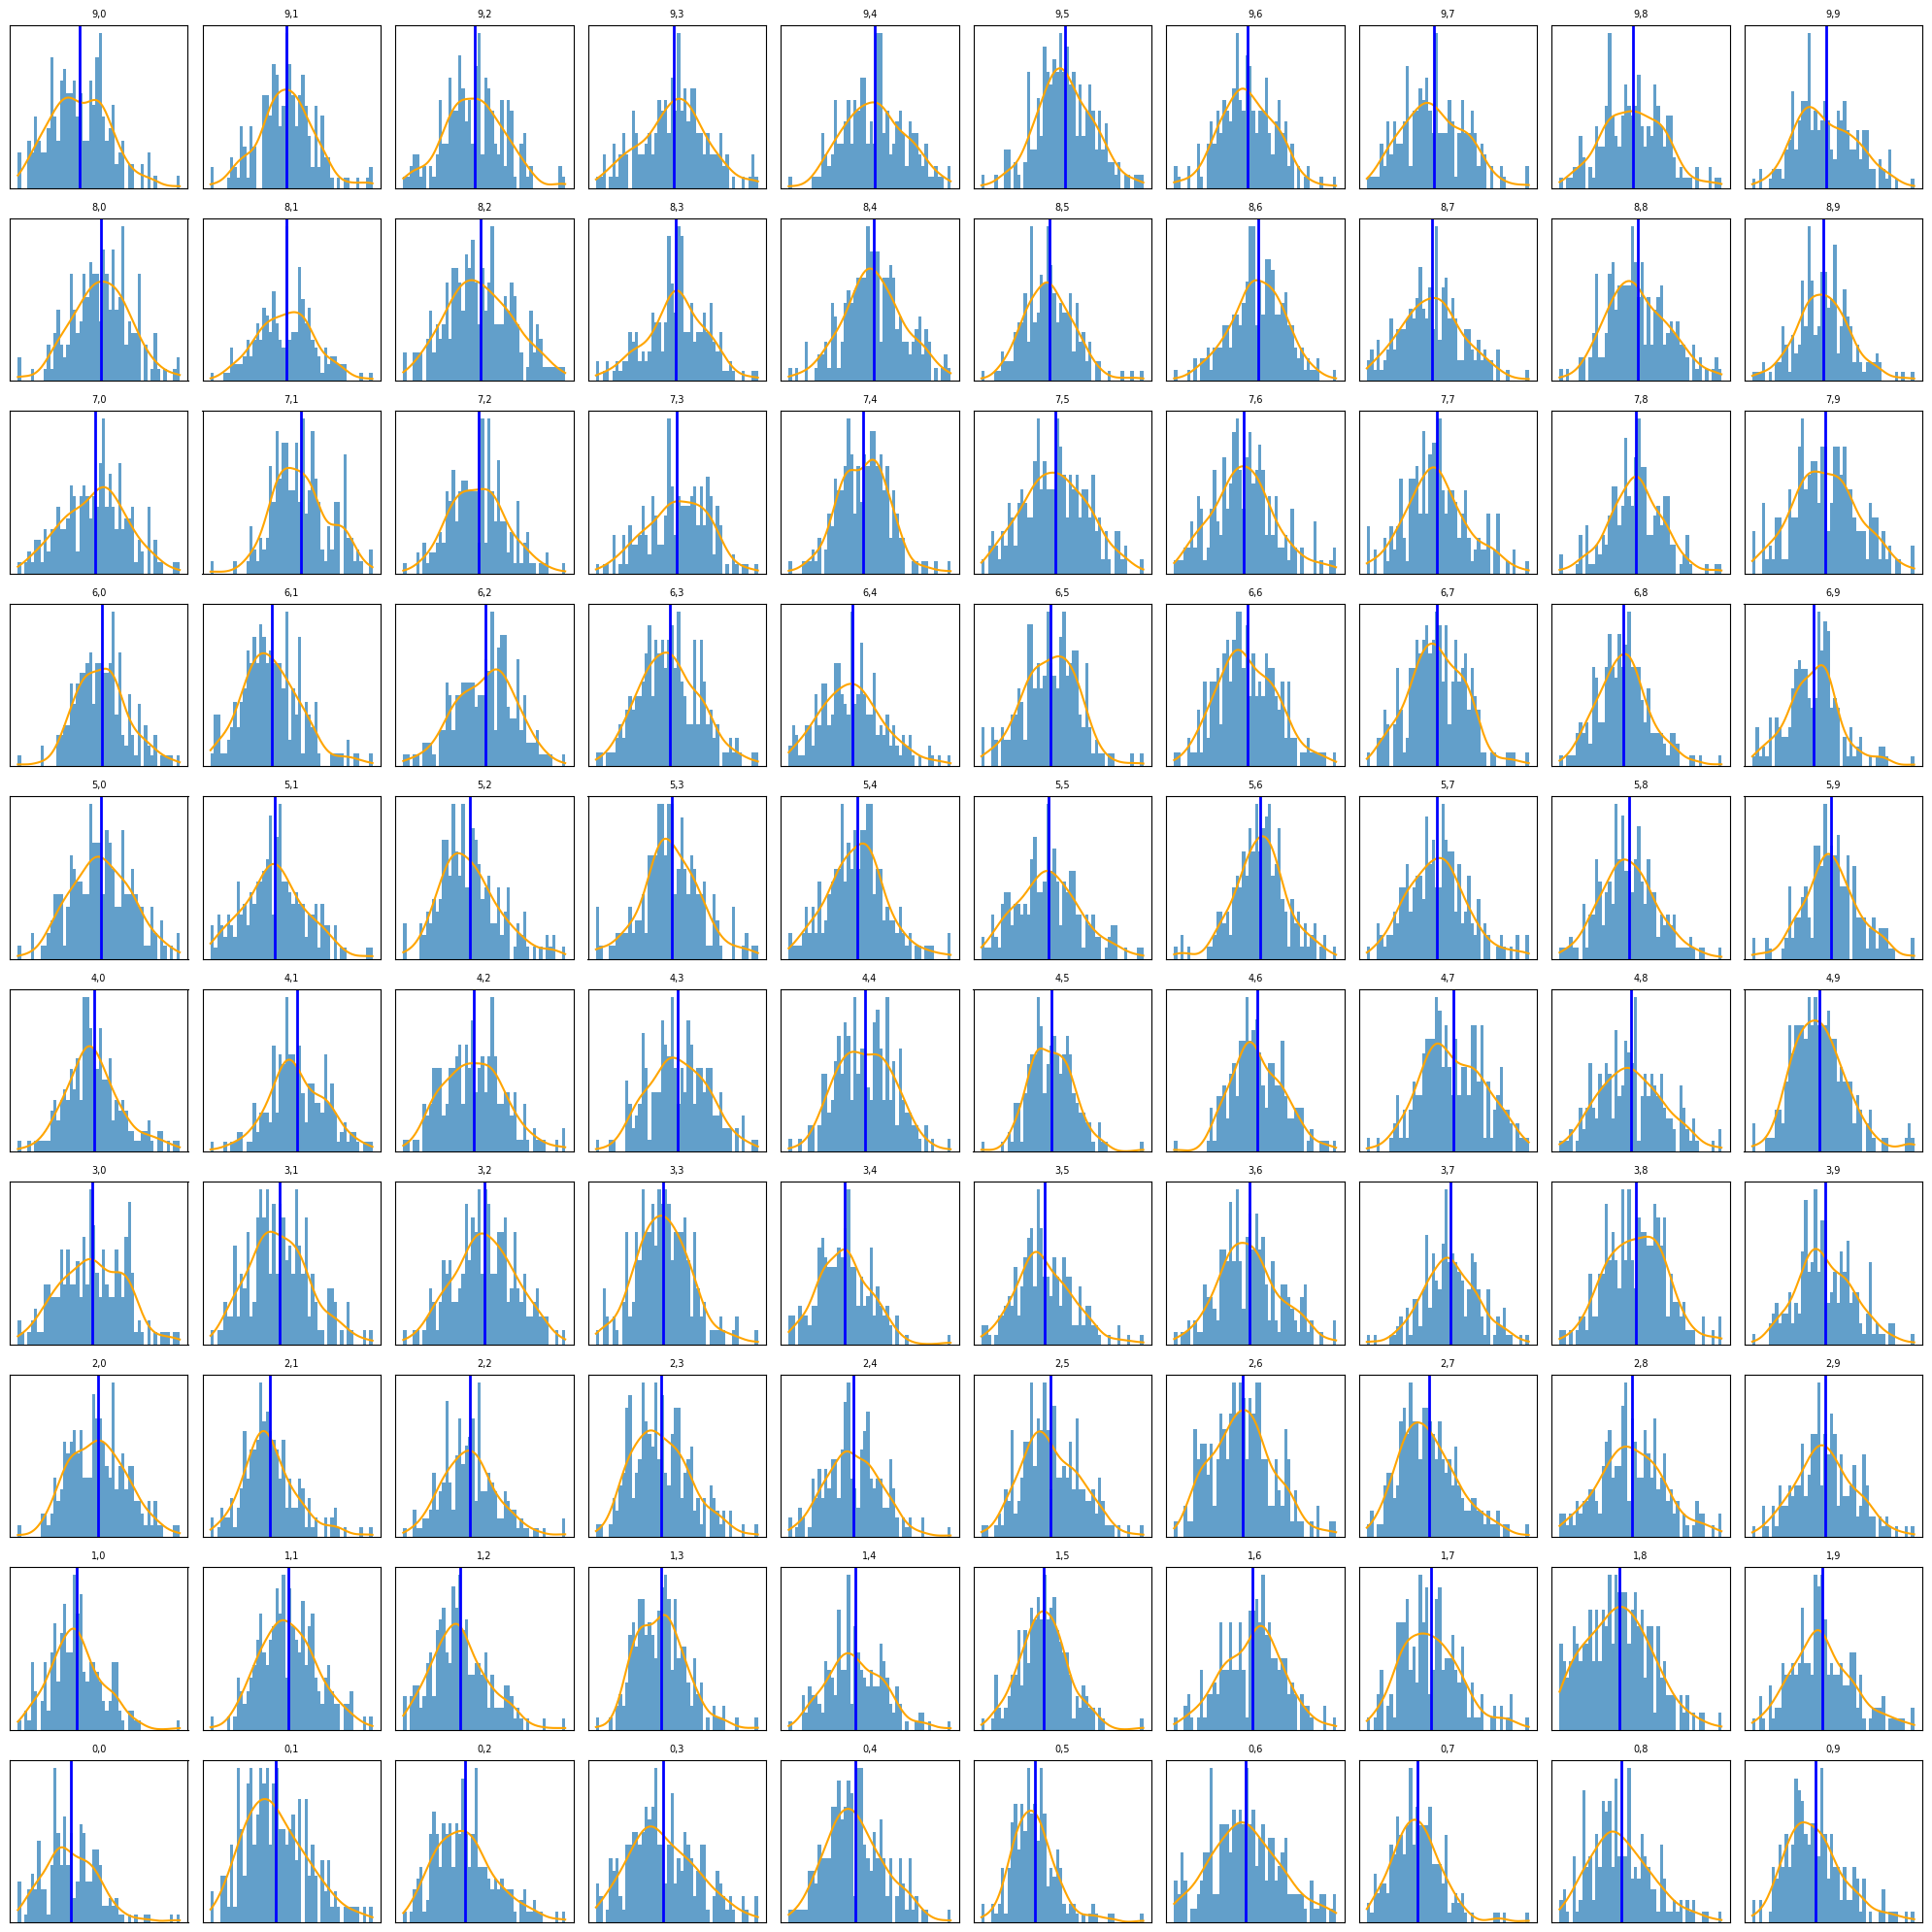

In [ ]:
from scipy.stats import lognorm, norm
from scipy.stats import gaussian_kde

z = 0
fig, axes = plt.subplots(10, 10, figsize=(20, 20))

EPS = 1e-8

for i in range(10):
    for j in range(10):
        ax = axes[9-i, j]         
        x = all_ps[:, z, i, j]
        mu = np.mean(x)
        sigma = np.std(x)
        ax.hist(x, bins=50, density=True, alpha=0.7)
        xx = np.linspace(x.min(), x.max(), 200)
        kde = gaussian_kde(x)
        ax.plot(xx, kde(xx), color='orange', linewidth=1.5, label='KDE')
        ax.axvline(mu, color='blue', linestyle='-', linewidth=2, label='Empirical Mean')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"{i},{j}", 
                     fontsize=7)

plt.tight_layout()
plt.show()